<a href="https://colab.research.google.com/github/shruti-2562/FML/blob/main/FML_practical_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Pumpkin_Seeds_Dataset (1).csv to Pumpkin_Seeds_Dataset (1).csv


In [ ]:
data = pd.read_csv(
    "Pumpkin_Seeds_Dataset (1).csv",
    encoding="latin1"
)

print("\nDATASET")
print(data)


DATASET
           Area Perimeter Major_Axis_Length Minor_Axis_Length Convex_Area  \
0     56276.0 m   888.2 m           326.1 m           220.2 m   56831.0 m   
1     76631.0 m  1068.1 m           417.2 m           234.2 m   77280.0 m   
2     71623.0 m  1083.0 m           435.8 m           211.0 m   72663.0 m   
3     66458.0 m   992.1 m           381.6 m           222.5 m   67118.0 m   
4     66107.0 m   998.1 m           383.9 m           220.5 m   67117.0 m   
...         ...       ...               ...               ...         ...   
2495  79637.0 m  1224.7 m           533.2 m           190.4 m   80381.0 m   
2496  69647.0 m  1084.3 m           462.9 m           191.8 m   70216.0 m   
2497  87994.0 m  1210.3 m           507.2 m           222.2 m   88702.0 m   
2498  80011.0 m  1182.9 m           501.9 m           204.8 m   80902.0 m   
2499  84934.0 m  1159.9 m           462.9 m           234.6 m   85781.0 m   

     Equiv_Diameter  Eccentricity  Solidity  Extent  Roundness  As

In [ ]:
print("\nDataset Shape:")
print(data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nFirst Five Records:")
print(data.head())

print("\nLast Five Records:")
print(data.tail())

print("\nDataset Information:")
data.info()

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nNumber of Duplicate Records:")
print(data.duplicated().sum())

print("\nStatistical Summary:")
print(data.describe())


Dataset Shape:
(2500, 15)

Column Names:
['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Convex_Area', 'Equiv_Diameter', 'Eccentricity', 'Solidity', 'Extent', 'Roundness', 'Aspect_Ration', 'Compactness', 'Class', 'Average Radius', '2xÏ\x80rÂ²']

First Five Records:
        Area Perimeter Major_Axis_Length Minor_Axis_Length Convex_Area  \
0  56276.0 m   888.2 m           326.1 m           220.2 m   56831.0 m   
1  76631.0 m  1068.1 m           417.2 m           234.2 m   77280.0 m   
2  71623.0 m  1083.0 m           435.8 m           211.0 m   72663.0 m   
3  66458.0 m   992.1 m           381.6 m           222.5 m   67118.0 m   
4  66107.0 m   998.1 m           383.9 m           220.5 m   67117.0 m   

  Equiv_Diameter  Eccentricity  Solidity  Extent  Roundness  Aspect_Ration  \
0        267.7 m           0.7       1.0     0.7        0.9            1.5   
1        312.4 m           0.8       1.0     0.7        0.8            1.8   
2        302.0 m           0.9       


Class Distribution:
Class
ÃerÃ§evelik       1300
ÃrgÃ¼p Sivrisi    1200
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 135 (\x87) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 156 (\x9c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


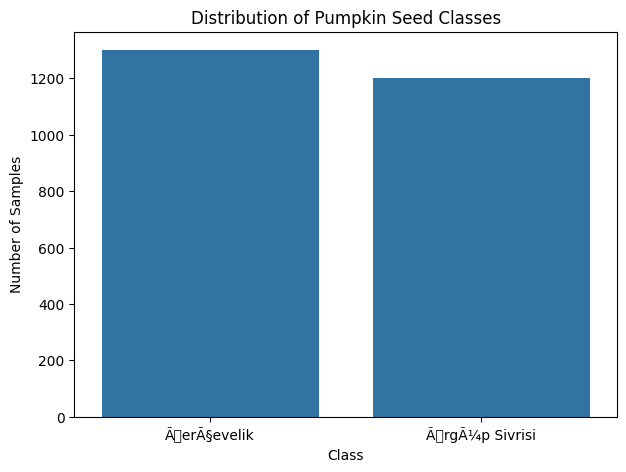

In [ ]:
print("\nClass Distribution:")
print(data["Class"].value_counts())


plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Class"
)

plt.title("Distribution of Pumpkin Seed Classes")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()


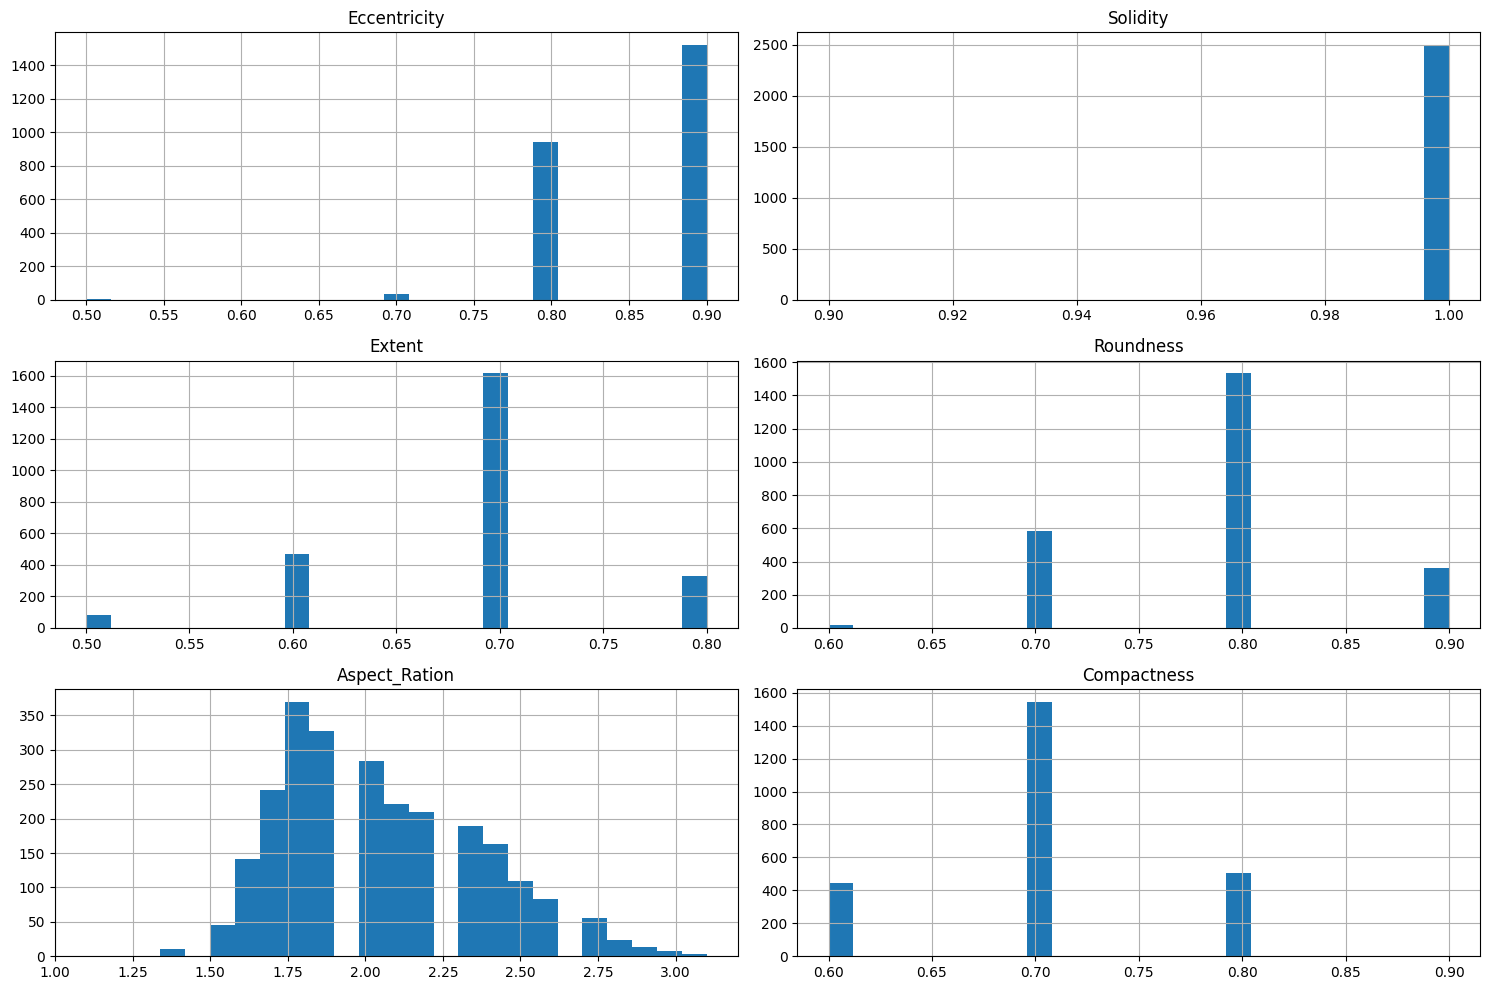

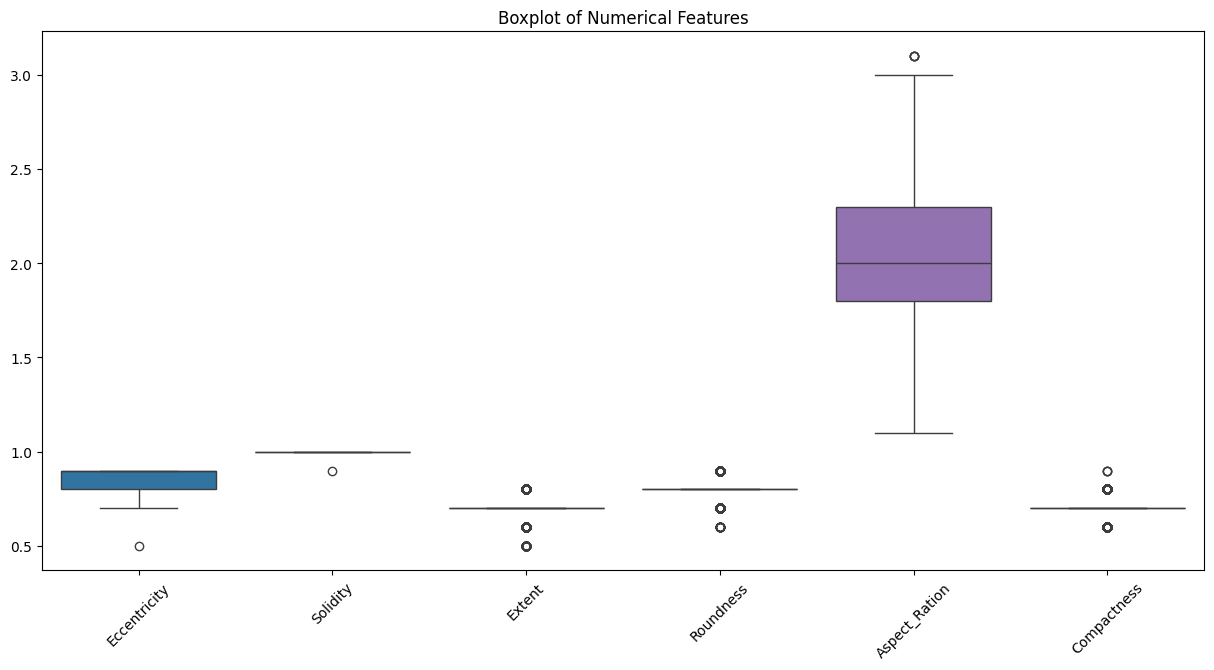

In [ ]:
numerical_columns = data.drop(
    "Class",
    axis=1
).select_dtypes(
    include=np.number
).columns

data[numerical_columns].hist(
    figsize=(15, 10),
    bins=25
)

plt.tight_layout()

plt.show()

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=data[numerical_columns]
)

plt.xticks(rotation=45)

plt.title("Boxplot of Numerical Features")

plt.show()



Correlation Matrix:
               Eccentricity  Solidity  Extent  Roundness  Aspect_Ration  \
Eccentricity          1.000    -0.016  -0.211     -0.592          0.760   
Solidity             -0.016     1.000   0.057      0.060         -0.054   
Extent               -0.211     0.057   1.000      0.260         -0.254   
Roundness            -0.592     0.060   0.260      1.000         -0.824   
Aspect_Ration         0.760    -0.054  -0.254     -0.824          1.000   
Compactness          -0.650     0.033   0.252      0.818         -0.863   

               Compactness  
Eccentricity        -0.650  
Solidity             0.033  
Extent               0.252  
Roundness            0.818  
Aspect_Ration       -0.863  
Compactness          1.000  


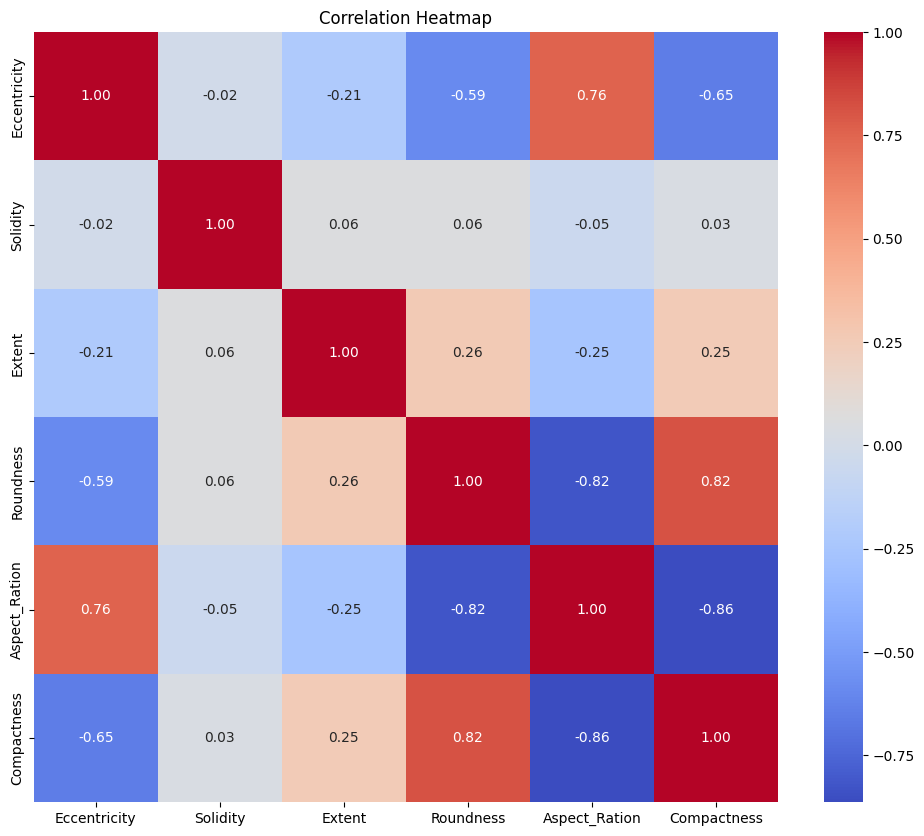

In [ ]:
input_data = data[numerical_columns]
correlation_matrix = input_data.corr()
print("\nCorrelation Matrix:")

print(
    correlation_matrix.round(3)
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
X = data.drop(
    "Class",
    axis=1
)
y = data["Class"]


print("\nInput Features:")
print(list(X.columns))


print("\nNumber of Input Features:")
print(X.shape[1])


print("\nInput Data Shape:")
print(X.shape)


print("\nTarget Data Shape:")
print(y.shape)


Input Features:
['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Convex_Area', 'Equiv_Diameter', 'Eccentricity', 'Solidity', 'Extent', 'Roundness', 'Aspect_Ration', 'Compactness', 'Average Radius', '2xÏ\x80rÂ²']

Number of Input Features:
14

Input Data Shape:
(2500, 14)

Target Data Shape:
(2500,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining Data Shape:")
print(X_train.shape)


print("\nTesting Data Shape:")
print(X_test.shape)


Training Data Shape:
(2000, 14)

Testing Data Shape:
(500, 14)


In [ ]:
columns_to_clean = [
    "Area",
    "Perimeter",
    "Major_Axis_Length",
    "Minor_Axis_Length",
    "Convex_Area",
    "Equiv_Diameter",
    "Average Radius",
    "2xÏ\x80rÂ²",
]

for col in columns_to_clean:

    if X_train[col].dtype == 'object':
        X_train[col] = X_train[col].str.replace(' m', '', regex=False).astype(float)
        X_test[col] = X_test[col].str.replace(' m', '', regex=False).astype(float)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
    X_train
)
X_test_scaled = scaler.transform(
    X_test
)


print("\nFeature Standardization Completed.")


Feature Standardization Completed.


In [ ]:
columns_to_clean = [
    "Area",
    "Perimeter",
    "Major_Axis_Length",
    "Minor_Axis_Length",
    "Convex_Area",
    "Equiv_Diameter",
    "Average Radius",
    "2xÏ\x80rÂ²",
]


for col in columns_to_clean:
    if X_train[col].dtype == 'object':
        X_train[col] = X_train[col].str.replace(' m', '', regex=False).astype(float)
        X_test[col] = X_test[col].str.replace(' m', '', regex=False).astype(float)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_without_pca = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=2000
)




model_without_pca.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=2000)

In [ ]:
train_prediction_without_pca = model_without_pca.predict(
    X_train_scaled
)


test_prediction_without_pca = model_without_pca.predict(
    X_test_scaled
)


Training Accuracy Without PCA:
0.874

Testing Accuracy Without PCA:
0.862

Classification Report Without PCA:
                 precision    recall  f1-score   support

   ÃerÃ§evelik       0.84      0.91      0.87       260
ÃrgÃ¼p Sivrisi       0.89      0.81      0.85       240

       accuracy                           0.86       500
      macro avg       0.87      0.86      0.86       500
   weighted avg       0.86      0.86      0.86       500



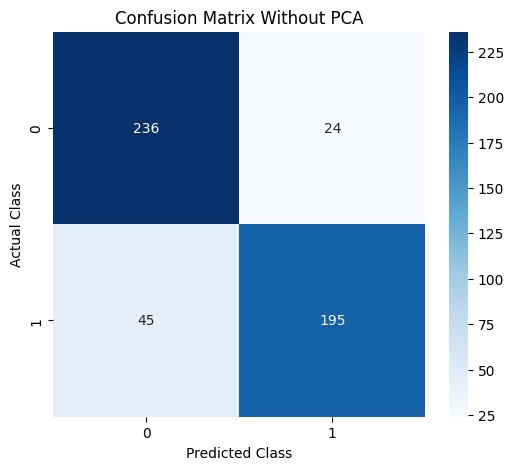

In [ ]:
training_accuracy_without_pca = accuracy_score(
    y_train,
    train_prediction_without_pca
)


testing_accuracy_without_pca = accuracy_score(
    y_test,
    test_prediction_without_pca
)


print("\nTraining Accuracy Without PCA:")
print(
    round(
        training_accuracy_without_pca,
        4
    )
)


print("\nTesting Accuracy Without PCA:")
print(
    round(
        testing_accuracy_without_pca,
        4
    )
)


print("\nClassification Report Without PCA:")

print(
    classification_report(
        y_test,
        test_prediction_without_pca
    )
)




confusion_without_pca = confusion_matrix(
    y_test,
    test_prediction_without_pca
)


plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_without_pca,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix Without PCA")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()


In [ ]:
pca_full = PCA()

pca_full.fit(
    X_train_scaled
)

explained_variance = (
    pca_full.explained_variance_ratio_
)


cumulative_variance = np.cumsum(
    explained_variance
)


print("\nExplained Variance:")

for i, value in enumerate(
    explained_variance,
    start=1
):
    print(
        f"Principal Component {i}: {value:.4f}"
    )


print("\nCumulative Explained Variance:")

for i, value in enumerate(
    cumulative_variance,
    start=1
):
    print(
        f"Components 1 to {i}: {value:.4f}"
    )


Explained Variance:
Principal Component 1: 0.5578
Principal Component 2: 0.3093
Principal Component 3: 0.0706
Principal Component 4: 0.0343
Principal Component 5: 0.0145
Principal Component 6: 0.0116
Principal Component 7: 0.0008
Principal Component 8: 0.0008
Principal Component 9: 0.0003
Principal Component 10: 0.0001
Principal Component 11: 0.0000
Principal Component 12: 0.0000
Principal Component 13: 0.0000
Principal Component 14: 0.0000

Cumulative Explained Variance:
Components 1 to 1: 0.5578
Components 1 to 2: 0.8671
Components 1 to 3: 0.9377
Components 1 to 4: 0.9720
Components 1 to 5: 0.9865
Components 1 to 6: 0.9980
Components 1 to 7: 0.9989
Components 1 to 8: 0.9996
Components 1 to 9: 0.9999
Components 1 to 10: 1.0000
Components 1 to 11: 1.0000
Components 1 to 12: 1.0000
Components 1 to 13: 1.0000
Components 1 to 14: 1.0000


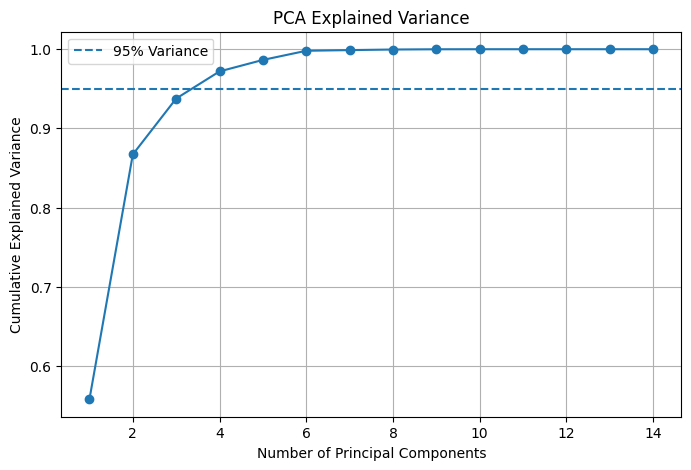

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA Explained Variance"
)

plt.legend()

plt.grid()

plt.show()

In [ ]:
pca = PCA(
    n_components=0.95
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)


X_test_pca = pca.transform(
    X_test_scaled
)


print("\nOriginal Number of Features:")
print(X.shape[1])


print("\nNumber of Principal Components:")
print(X_train_pca.shape[1])


print("\nTotal Variance Retained:")
print(
    round(
        np.sum(
            pca.explained_variance_ratio_
        ),
        4
    )
)



Original Number of Features:
14

Number of Principal Components:
4

Total Variance Retained:
0.972


In [ ]:
model_with_pca = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=2000
)


model_with_pca.fit(
    X_train_pca,
    y_train
)

LogisticRegression(max_iter=2000)

In [ ]:
train_prediction_with_pca = model_with_pca.predict(
    X_train_pca
)


test_prediction_with_pca = model_with_pca.predict(
    X_test_pca
)



Training Accuracy With PCA:
0.8535

Testing Accuracy With PCA:
0.84

Classification Report With PCA:
                 precision    recall  f1-score   support

   ÃerÃ§evelik       0.86      0.83      0.84       260
ÃrgÃ¼p Sivrisi       0.82      0.85      0.84       240

       accuracy                           0.84       500
      macro avg       0.84      0.84      0.84       500
   weighted avg       0.84      0.84      0.84       500



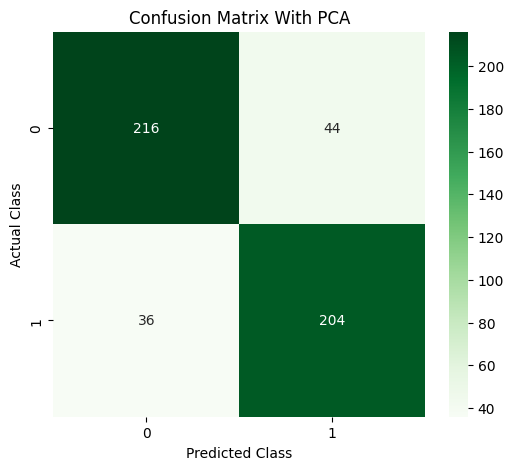

In [ ]:
training_accuracy_with_pca = accuracy_score(
    y_train,
    train_prediction_with_pca
)


testing_accuracy_with_pca = accuracy_score(
    y_test,
    test_prediction_with_pca
)


print("\nTraining Accuracy With PCA:")
print(
    round(
        training_accuracy_with_pca,
        4
    )
)


print("\nTesting Accuracy With PCA:")
print(
    round(
        testing_accuracy_with_pca,
        4
    )
)


print("\nClassification Report With PCA:")

print(
    classification_report(
        y_test,
        test_prediction_with_pca
    )
)



confusion_with_pca = confusion_matrix(
    y_test,
    test_prediction_with_pca
)


plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_with_pca,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix With PCA")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [ ]:
generalization_gap_without_pca = (
    training_accuracy_without_pca
    - testing_accuracy_without_pca
)


generalization_gap_with_pca = (
    training_accuracy_with_pca
    - testing_accuracy_with_pca
)


print("\nGeneralization Gap Without PCA:")
print(
    round(
        generalization_gap_without_pca,
        4
    )
)


print("\nGeneralization Gap With PCA:")
print(
    round(
        generalization_gap_with_pca,
        4
    )
)



Generalization Gap Without PCA:
0.012

Generalization Gap With PCA:
0.0135


In [ ]:
comparison = pd.DataFrame({

    "Model": [
        "Without PCA",
        "With PCA"
    ],

    "Number of Features": [
        X.shape[1],
        X_train_pca.shape[1]
    ],

    "Training Accuracy": [
        training_accuracy_without_pca,
        training_accuracy_with_pca
    ],

    "Testing Accuracy": [
        testing_accuracy_without_pca,
        testing_accuracy_with_pca
    ],

    "Generalization Gap": [
        generalization_gap_without_pca,
        generalization_gap_with_pca
    ]
})


print("\nFinal Performance Comparison:")

print(
    comparison.round(4)
)



Final Performance Comparison:
         Model  Number of Features  Training Accuracy  Testing Accuracy  \
0  Without PCA                  14             0.8740             0.862   
1     With PCA                   4             0.8535             0.840   

   Generalization Gap  
0              0.0120  
1              0.0135  


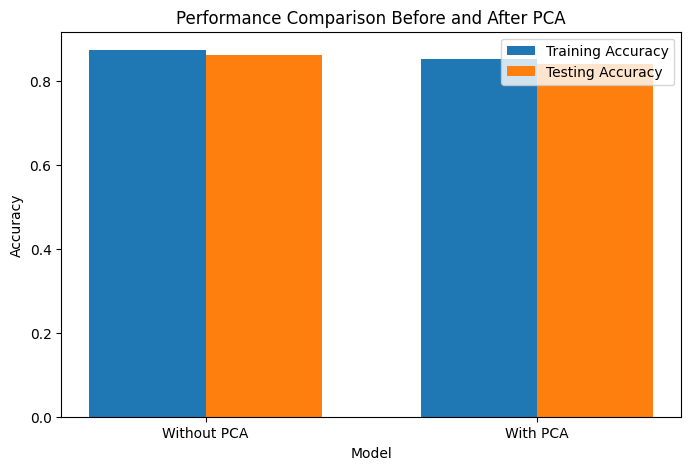

In [ ]:
model_names = [
    "Without PCA",
    "With PCA"
]


training_scores = [
    training_accuracy_without_pca,
    training_accuracy_with_pca
]


testing_scores = [
    testing_accuracy_without_pca,
    testing_accuracy_with_pca
]


x = np.arange(
    len(model_names)
)


width = 0.35


plt.figure(figsize=(8, 5))


plt.bar(
    x - width / 2,
    training_scores,
    width,
    label="Training Accuracy"
)


plt.bar(
    x + width / 2,
    testing_scores,
    width,
    label="Testing Accuracy"
)


plt.xticks(
    x,
    model_names
)


plt.xlabel("Model")

plt.ylabel("Accuracy")

plt.title(
    "Performance Comparison Before and After PCA"
)


plt.legend()

plt.show()


In [ ]:
print("\nOriginal Number of Features:")
print(X.shape[1])


print("\nNumber of Features After PCA:")
print(X_train_pca.shape[1])


print("\nTesting Accuracy Without PCA:")
print(
    round(
        testing_accuracy_without_pca,
        4
    )
)


print("\nTesting Accuracy With PCA:")
print(
    round(
        testing_accuracy_with_pca,
        4
    )
)


print("\nGeneralization Gap Without PCA:")
print(
    round(
        generalization_gap_without_pca,
        4
    )
)


print("\nGeneralization Gap With PCA:")
print(
    round(
        generalization_gap_with_pca,
        4
    )
)



if testing_accuracy_with_pca > testing_accuracy_without_pca:

    print("\nConclusion:")

    print(
        "PCA reduced the number of features and improved "
        "the testing performance of the model."
    )


elif testing_accuracy_with_pca == testing_accuracy_without_pca:

    print("\nConclusion:")

    print(
        "PCA reduced the number of features while maintaining "
        "the same testing performance."
    )


else:

    print("\nConclusion:")

    print(
        "PCA successfully reduced the dimensionality, although "
        "the testing accuracy did not improve."
    )


Original Number of Features:
14

Number of Features After PCA:
4

Testing Accuracy Without PCA:
0.862

Testing Accuracy With PCA:
0.84

Generalization Gap Without PCA:
0.012

Generalization Gap With PCA:
0.0135

Conclusion:
PCA successfully reduced the dimensionality, although the testing accuracy did not improve.
